# Звіт про виконання практичного завдання №1 

## "Лінійна регресія, оптимізація та статистичний аналіз" 

### з дисципліни "Машинне навчання"

### Виконав:

### студент групи ФеІ-42

### Муртазін Максим

Мета роботи: Зрозуміти архітектуру лінійної регресії, навчитися самостійно реалізовувати алгоритми оптимізації, обирати інформативні ознаки, обчислювати метрики якості та перевіряти статистичні припущення моделі.

### Опис датасету

Набір даних: *Ames Housing Dataset* (House Prices: Advanced Regression Techniques).

Завдання: прогнозування вартості житлової нерухомості (завдання регресії).

Цільова змінна ($y$): SalePrice - фактична ціна продажу будинку в доларах США.

Хід роботи:

## 1. Підготовка робочого середовища
Для виконання роботи використовуються базові бібліотеки наукового стека Python:
* NumPy - матричні операції, векторизовані математичні обчислення та власна реалізація алгоритмів оптимізації.
* Pandas - завантаження, структурування та маніпуляції з табличними даними.
* Matplotlib та Seaborn - візуалізація розподілів, кореляцій і кривих навчання.
* SciPy - перевірка статистичних гіпотез та оцінка параметрів розподілу.
* scikit-learn - розбиття вибірки, кодування категоріальних ознак і стандартизація числових даних.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Налаштування візуалізації
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Завантаження датасету
df_raw = pd.read_csv('train.csv')
print(f"Розмірність завантаженого датасету: {df_raw.shape[0]} рядків, {df_raw.shape[1]} колонок.")

# Базовий огляд структури датасету
print(df_raw.info())
display(df_raw.describe().T.head(10))

Розмірність завантаженого датасету: 1460 рядків, 81 колонок.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   obje

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 2. Етап 1. Дослідження даних (EDA), відбір ознак та попередня обробка

### 2.1. Первинний аналіз структури та цільової змінної
Датасет містить 1460 спостережень та 81 ознаку (80 потенційних предикторів та 1 цільову змінну SalePrice).

Аналіз якості даних показав наявність суттєвих пропусків у низці колонок:

&nbsp;&nbsp;&nbsp;&nbsp;Ознаки PoolQC (99.5%), MiscFeature (96.3%), Alley (93.8%) та Fence (80.8%) мають критичну частку відсутніх значень (>80%), тому їхнє використання без додаткових складних реконструкцій є недоцільним.
Для таких ознак, як FireplaceQu (47.3%) та LotFrontage (17.7%), відсутність значення найчастіше означає фізичну відсутність об'єкта (наприклад, каміна).

Аналіз розподілу цільової змінної SalePrice:

&nbsp;&nbsp;&nbsp;&nbsp;Асиметрія (Skewness = 1.883): розподіл має виражену правосторонню асиметрію (довгий правий хвіст). Більшість будинків зосереджена в ціновому діапазоні від 130 000 до 215 000, проте присутні дорогі об'єкти вартістю понад 500 000\$.

&nbsp;&nbsp;&nbsp;&nbsp;Ексцес (Kurtosis = 6.536): значення суттєво перевищує норму для нормального розподілу ($Kurtosis > 3$), що підтверджує наявність «важкого правого хвоста» та поодиноких викидів.

&nbsp;&nbsp;&nbsp;&nbsp;Q-Q графік: точки відхиляються від прямої лінії у верхньому квартільовому діапазоні, що свідчить про помірне порушення припущення про нормальність цільової змінної в її вихідній шкалі.

Топ-10 ознак за кількістю пропусків:
              Missing Values  Percent (%)
PoolQC                  1453    99.520548
MiscFeature             1406    96.301370
Alley                   1369    93.767123
Fence                   1179    80.753425
MasVnrType               872    59.726027
FireplaceQu              690    47.260274
LotFrontage              259    17.739726
GarageType                81     5.547945
GarageYrBlt               81     5.547945
GarageFinish              81     5.547945


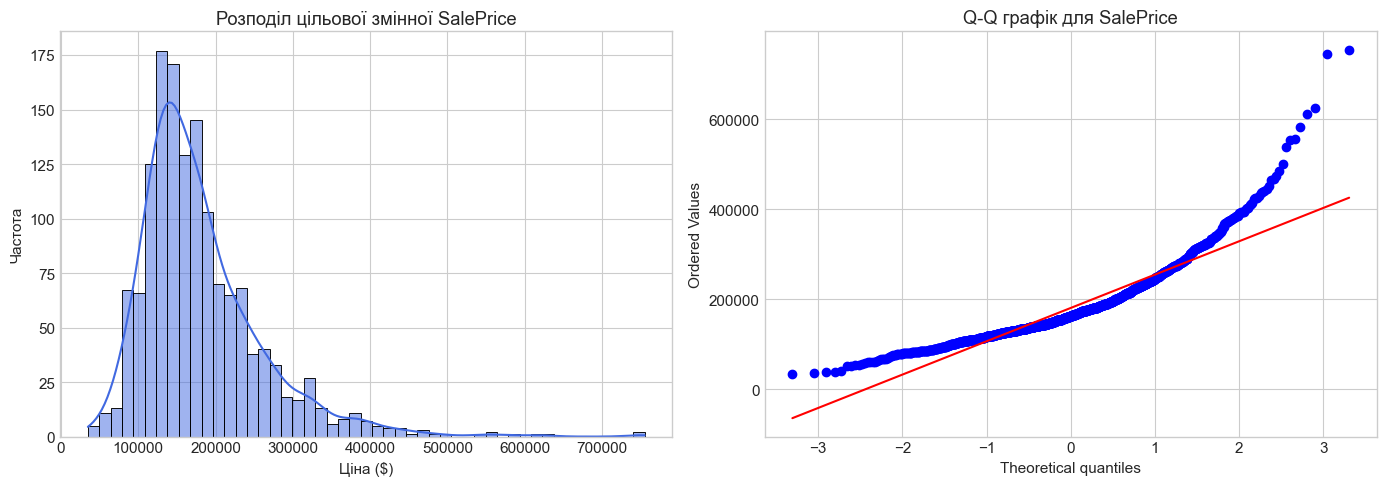

Асиметрія (Skewness): 1.883 (правостороння асиметрія)
Ексцес (Kurtosis): 6.536


In [44]:
# Перевірка типів даних та інформація про пропуски
missing_series = df_raw.isnull().sum()
missing_features = missing_series[missing_series > 0].sort_values(ascending=False)
missing_pct = (missing_features / len(df_raw)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_features, 'Percent (%)': missing_pct})
print("Топ-10 ознак за кількістю пропусків:")
print(missing_df.head(10))

# Аналіз розподілу цільової змінної
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_raw['SalePrice'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Розподіл цільової змінної SalePrice')
axes[0].set_xlabel('Ціна ($)')
axes[0].set_ylabel('Частота')

stats.probplot(df_raw['SalePrice'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q графік для SalePrice')

plt.tight_layout()
plt.show()

skewness = df_raw['SalePrice'].skew()
kurt = df_raw['SalePrice'].kurt()
print(f"Асиметрія (Skewness): {skewness:.3f} (правостороння асиметрія)")
print(f"Ексцес (Kurtosis): {kurt:.3f}")

### 2.2. Розбиття вибірки та запобігання витоку даних

#### Теоретичне обґрунтування:
Питання: Чому розбиття даних має відбуватися суворо до масштабування, кодування чи інших операцій попередньої обробки? Що таке Data Leakage?

**Витік даних (Data Leakage)** - це методологічна помилка, за якої інформація з тестового чи валідаційного набору випадково потрапляє в процес навчання моделі або налаштування попередьої обробки. 

Якщо нормалізація, заповнення пропусків або кодування категорій виконуються на всьому датасеті до його розділення:
1. Статистичні параметри контрольних вибірок (наприклад, середнє значення $\mu$ та дисперсія $\sigma^2$ для стандартизації або медіана для заповнення пропусків) стають відомими моделі під час трансформації навчальних даних.
2. Валідаційний і тестовий набори перестають бути незалежними, що призводить до отримання штучно оптимістичних метрик під час розробки.
3. На практиці точність прогнозування такої моделі різко падає, оскільки вона виявляється нестійкою до невідомих даних.

Масив даних розділено у класичній пропорції **70% / 15% / 15%**:
* Навчальна вибірка (Train - 1022 об'єкти): використовується для розрахунку параметрів перетворень, відбору ознак та оновлення ваг моделі.
* Валідаційна вибірка (Validation - 219 об'єктів): слугує для тонкого налаштування гіперпараметрів і контролю перенавчання.
* Тестова вибірка (Test - 219 об'єктів): залишається ізольованою для фінальної об'єктивної перевірки узагальнюючої здатності алгоритму.

In [45]:
from sklearn.model_selection import train_test_split

# Виділення ознак та цільової змінної
X = df_raw.drop(columns=['Id', 'SalePrice'])
y = df_raw['SalePrice'].values.reshape(-1, 1)

# Розбиття 70% Train, 15% Validation, 15% Test
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Розмір навчальної вибірки (Train): {X_train_raw.shape[0]} об'єктів")
print(f"Розмір валідаційної вибірки (Val):  {X_val_raw.shape[0]} об'єктів")
print(f"Розмір тестової вибірки (Test):     {X_test_raw.shape[0]} об'єктів")

Розмір навчальної вибірки (Train): 1022 об'єктів
Розмір валідаційної вибірки (Val):  219 об'єктів
Розмір тестової вибірки (Test):     219 об'єктів


### 2.3. Відбір інформативних ознак (Feature Selection)

Відбір ознак виконується виключно на навчальній підвибірці з дотриманням двох критеріїв:
1. Висока кореляція з цільовою змінною SalePrice (інформативність предиктора).
2. Мінімальна кореляція між самими предикторами (запобігання ефекту мультиколінеарності).

#### Результати аналізу кореляцій Пірсона на вибірці Train:
Найсильніший лінійний зв'язок із вартістю житла демонструють такі показники:
* OverallQual ($r = 0.78$) — загальна оцінка якості матеріалів та оздоблення будинку.
* GrLivArea ($r = 0.69$) — загальна житлова площа над рівнем землі.
* GarageCars ($r = 0.64$) / GarageArea ($r = 0.62$) — місткість та площа гаража.
* TotalBsmtSF ($r = 0.59$) / 1stFlrSF ($r = 0.58$) — загальна площа підвалу та площа першого поверху.
* FullBath ($r = 0.55$) — кількість повноцінних санвузлів.
* YearBuilt ($r = 0.51$) — рік побудови споруди.

#### Усунення мультиколінеарних дублікатів:
Між парами GarageCars - GarageArea ($r = 0.88$) та TotalBsmtSF - 1stFlrSF ($r = 0.82$) зафіксовано надзвичайно сильний взаємний зв'язок. Щоб уникнути нестабільності ваг регресії, з моделі виключено ознаки GarageArea та 1stFlrSF. 

До фінального числового набору увійшли 6 ключових метрик: OverallQual, GrLivArea, TotalBsmtSF, GarageCars, YearBuilt, FullBath.

Топ ознак за кореляцією з SalePrice на Train:
SalePrice       1.000000
OverallQual     0.784720
GrLivArea       0.689238
GarageCars      0.642689
GarageArea      0.621937
TotalBsmtSF     0.590017
1stFlrSF        0.583132
FullBath        0.549164
TotRmsAbvGrd    0.519634
YearBuilt       0.512206
Name: SalePrice, dtype: float64


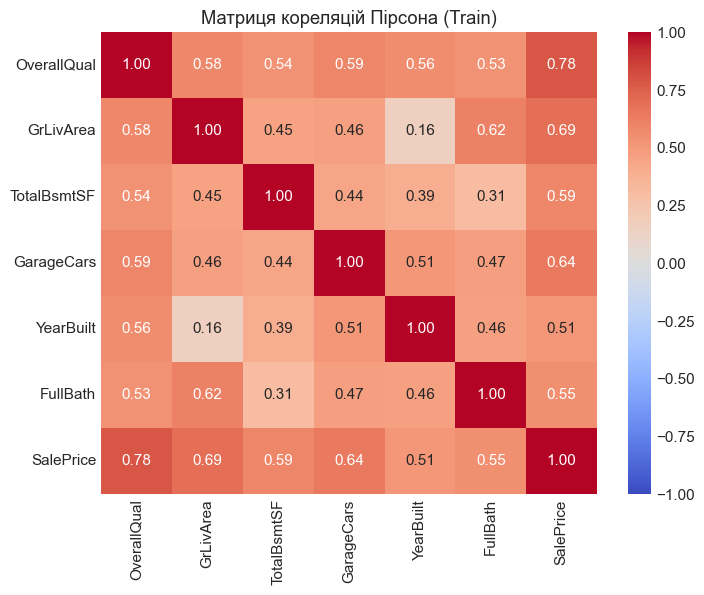

In [46]:
# Об'єднуємо train ознаки з y_train суто для аналізу кореляцій
train_eda = X_train_raw.copy()
train_eda['SalePrice'] = y_train

# Кореляція числових ознак з SalePrice
num_cols_all = train_eda.select_dtypes(include=[np.number]).columns
corr_matrix = train_eda[num_cols_all].corr()
top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(10)

print("Топ ознак за кореляцією з SalePrice на Train:")
print(top_corr_features)

# Візуалізація кореляційної матриці відібраних ознак
selected_num_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
plt.figure(figsize=(8, 6))
sns.heatmap(train_eda[selected_num_features + ['SalePrice']].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Матриця кореляцій Пірсона (Train)')
plt.show()

### 2.4. Обробка категоріальних даних, пропусків та масштабування

#### Обґрунтування методів кодування:
1. Порядкове кодування (Ordinal Encoding):

    Застосовано до ознак ExterQual (якість зовнішнього оздоблення) та KitchenQual (якість кухні). Градації цих категорій мають чіткий природний порядок (Po < Fa < TA < Gd < Ex), тому відображення їх у числа від 1 до 5 коректно передає поступове зростання цінності будинку, не збільшуючи розмірність простору ознак.

3. Пряме бінарне кодування (One-Hot Encoding):

    Застосовано до номінальних ознак Neighborhood (район) та BldgType (тип будинку). Оскільки між назвами районів немає відношення порядку, призначення їм штучних чисел призвело б до виникнення хибних лінійних залежностей. One-Hot створює незалежні бінарні стовпчики для кожної категорії.

---

#### Відповідь на теоретичне питання:
Питання: Як ви будете обробляти категорії, які з'являться на валідації/тесті, але яких не було в Train?

Для One-Hot Encoding: у трансформері зафіксовано параметр handle_unknown='ignore'. Якщо на валідації або тесті з'являється невідомий район чи тип споруди, усі відповідні бінарні стовпчики отримують нульові значення ($0$). Це дозволяє зберегти фіксовану кількість стовпчиків у матриці ознак і коректно виконати скалярний добуток із вектором навчених ваг $w$.

Для Ordinal Encoding: невідомі значення автоматично приводяться до базового рангу TA (найчастішої модальної оцінки в навчальних даних), що запобігає появі пропусків NaN.

---

#### Заповнення пропусків та масштабування:
* Пропуски у числових ознаках заповнюються медіаною, обчисленою на Train (медіана стійка до екстремальних викидів).
* Усі безперервні та порядкові змінні масштабуються методом стандартизації ($z = \frac{x - \mu}{\sigma}$) за допомогою StandardScaler. Параметри $\mu$ (середнє) та $\sigma$ (стандартне відхилення) оцінюються виключно на Train і фіксуються для тестового застосування.

Результат підготовки даних:
Отримано збалансовані матриці вхідних даних розмірністю 38 колонок (X_train: $1022 \times 38$, X_val: $219 \times 38$, X_test: $219 \times 38$), готові для векторизованих матричних обчислень у NumPy.

In [47]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

selected_ordinal_features = ['ExterQual', 'KitchenQual']
selected_nominal_features = ['Neighborhood', 'BldgType']

# Словник для порядкового кодування
quality_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

def apply_ordinal_encoding(df, cols, mapping):
    df_out = df.copy()
    for c in cols:
        # Заповнення можливих пропусків модою 'TA', мапинг значень
        df_out[c] = df_out[c].fillna('TA').map(mapping).fillna(3).astype(float)
    return df_out

# 1. Порядкове кодування
X_train_ord = apply_ordinal_encoding(X_train_raw[selected_ordinal_features], selected_ordinal_features, quality_map)
X_val_ord = apply_ordinal_encoding(X_val_raw[selected_ordinal_features], selected_ordinal_features, quality_map)
X_test_ord = apply_ordinal_encoding(X_test_raw[selected_ordinal_features], selected_ordinal_features, quality_map)

# 2. Обробка пропусків у числових ознаках
num_imputer = SimpleImputer(strategy='median')
X_train_num_imp = num_imputer.fit_transform(X_train_raw[selected_num_features])
X_val_num_imp = num_imputer.transform(X_val_raw[selected_num_features])
X_test_num_imp = num_imputer.transform(X_test_raw[selected_num_features])

# Об'єднання числових та порядкових ознак для масштабування
X_train_continuous = np.hstack([X_train_num_imp, X_train_ord.values])
X_val_continuous = np.hstack([X_val_num_imp, X_val_ord.values])
X_test_continuous = np.hstack([X_test_num_imp, X_test_ord.values])

# 3. Стандартизація (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_continuous)
X_val_scaled = scaler.transform(X_val_continuous)
X_test_scaled = scaler.transform(X_test_continuous)

# 4. One-Hot кодування номінальних категорій
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train_raw[selected_nominal_features].fillna('Missing'))
X_val_ohe = ohe.transform(X_val_raw[selected_nominal_features].fillna('Missing'))
X_test_ohe = ohe.transform(X_test_raw[selected_nominal_features].fillna('Missing'))

# 5. Фінальна конкатенація оброблених ознак у матриці для NumPy
X_train = np.hstack([X_train_scaled, X_train_ohe])
X_val = np.hstack([X_val_scaled, X_val_ohe])
X_test = np.hstack([X_test_scaled, X_test_ohe])

print("Підготовка даних успішно завершена:")
print(f"X_train фінальна розмірність: {X_train.shape}")
print(f"X_val   фінальна розмірність: {X_val.shape}")
print(f"X_test  фінальна розмірність: {X_test.shape}")

Підготовка даних успішно завершена:
X_train фінальна розмірність: (1022, 38)
X_val   фінальна розмірність: (219, 38)
X_test  фінальна розмірність: (219, 38)


## 3. Етап 2. Реалізація лінійної регресії засобами NumPy

### 3.1. Математична формалізація моделі та векторизація

Лінійна регресія апроксимує залежність між вектором ознак та неперервною цільовою змінною за допомогою лінійної комбінації параметрів:
$$\hat{y} = Xw + b$$

де:
* $X \in \mathbb{R}^{m \times n}$ - матриця вхідних ознак ($m$ спостережень, $n$ ознак);
* $w \in \mathbb{R}^{n \times 1}$ - вектор вагових коефіцієнтів моделі;
* $b \in \mathbb{R}$ - вільний член (інтерцепт / зміщення);
* $\hat{y} \in \mathbb{R}^{m \times 1}$ - вектор прогнозів моделі.

#### Функція втрат (Cost Function)
Як міру похибки обрано функцію середньоквадратичної помилки (MSE) з додатковим коефіцієнтом $\frac{1}{2}$ для спрощення аналітичного диференціювання:
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)^2 = \frac{1}{2m} (Xw + b\mathbf{1} - y)^T (Xw + b\mathbf{1} - y)$$
де $\mathbf{1} \in \mathbb{R}^{m \times 1}$ - вектор одиниць, а $y \in \mathbb{R}^{m \times 1}$ - вектор фактичних значень цільової змінної.

#### Аналітичне обчислення градієнтів
Градієнти функції втрат за параметрами $w$ та $b$ виводяться за правилами матричного диференціювання. Позначимо вектор залишків (помилок прогнозу) як $e = \hat{y} - y \in \mathbb{R}^{m \times 1}$:

1. **Градієнт за вектором ваг $w$:**
   $$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y) = \frac{1}{m} X^T e$$
   *Розмірність:* $(n \times m) \times (m \times 1) = n \times 1$, що суворо відповідає формі вектора $w$.

2. **Градієнт за вільним членом $b$:**
   $$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right) = \frac{1}{m} \mathbf{1}^T e$$
   *Розмірність:* скалярне значення, еквівалентне середній помилці прогнозу по всій вибірці.

#### Оновлення параметрів (Gradient Descent Step)
На кожній ітерації оптимізації параметри коригуються у напрямку, протилежному до вектора градієнта:
$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \quad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$
де $\alpha > 0$ - швидкість навчання (Learning Rate).

Використання циклів for для обчислення прогнозів, функції втрат або градієнтів повністю виключено. Усі операції реалізовано через скалярні та матричні добутки NumPy, що забезпечує використання низькорівневих оптимізованих бібліотек BLAS/LAPACK та суттєво прискорює розрахунки.

---

### 3.2. Бонус: Аналітичне виведення Normal Equation та аналіз його обмежень

**Normal Equation (нормальне рівняння)** - це аналітичний метод пошуку оптимальних параметрів лінійної регресії за критерієм найменших квадратів, що не вимагає ітеративного налаштування гіперпараметра $\alpha$.

#### 1. Математичне виведення:
Для компактності об'єднаємо вільний член $b$ та ваги $w$ в єдиний вектор параметрів $\theta \in \mathbb{R}^{(n+1) \times 1}$, а до матриці ознак $X$ додамо перший фіктивний стовпчик з одиниць:
$$\tilde{X} = \begin{bmatrix} \mathbf{1} & X \end{bmatrix} \in \mathbb{R}^{m \times (n+1)}, \quad \theta = \begin{bmatrix} b \\ w \end{bmatrix} \in \mathbb{R}^{(n+1) \times 1} \implies \hat{y} = \tilde{X}\theta$$

Функція втрат у векторно-матричній формі:
$$J(\theta) = \frac{1}{2m} (\tilde{X}\theta - y)^T (\tilde{X}\theta - y) = \frac{1}{2m} \left( \theta^T \tilde{X}^T \tilde{X} \theta - 2 y^T \tilde{X} \theta + y^T y \right)$$

Знайдемо матричну похідну $\nabla_\theta J(\theta)$ і прирівняємо її до нуля для знаходження глобального оптимуму:
$$\nabla_\theta J(\theta) = \frac{1}{m} \left( \tilde{X}^T \tilde{X} \theta - \tilde{X}^T y \right) = 0$$
$$\tilde{X}^T \tilde{X} \theta = \tilde{X}^T y$$

Якщо матриця $\tilde{X}^T \tilde{X}$ є невиродженою (квадратна матриця розміром $(n+1) \times (n+1)$ має повний ранг), помножимо обидві частини рівняння зліва на обернену матрицю $(\tilde{X}^T \tilde{X})^{-1}$:
$$\theta = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T y$$

---

#### 2. Аналіз фундаментальних обмежень Normal Equation:
Незважаючи на простоту однократного обчислення розв'язку без підбору швидкості навчання та кількості епох, Normal Equation має суттєві недоліки:

1. Висока обчислювальна складність:

   Обчислення добутку $\tilde{X}^T \tilde{X}$ вимагає $\mathcal{O}(m n^2)$ операцій, а обернення матриці $(\tilde{X}^T \tilde{X})^{-1}$ — $\mathcal{O}(n^3)$ (або $\mathcal{O}(n^{2.81})$ за алгоритмом Штрассена).
   При великій кількості ознак (наприклад, $n > 10\,000$) метод стає обчислювально неефективним або взагалі нездійсненним, тоді як градієнтний спуск масштабується зі складністю $\mathcal{O}(k \cdot mn)$, де $k$ - число епох.

3. Проблема сингулярності (виродженості матриці):

    Матриця $\tilde{X}^T \tilde{X}$ не має оберненої (є невизначеною), якщо:
     * Кількість ознак перевищує кількість спостережень ($n > m$);
     * Присутня сильна мультиколінеарність (лінійна залежність між предикторами), наприклад, одночасне включення взаємозалежних ознак площі чи невидалена базова категорія в One-Hot Encoding.

    У такому разі доводиться використовувати псевдообернену матрицю Мура - Пенроуза, що збільшує похибку чисельного округлення та робить коефіцієнти моделі нестійкими.

5. Обмеження за оперативною пам'яттю (Out-of-Memory):

   Метод вимагає завантаження всього масиву $\tilde{X}$ в оперативну пам'ять для виконання матричного множення, що унеможливлює його роботу з великими датасетами (Big Data) у потоковому або пакетному (mini-batch) режимі.

In [48]:
class LinearRegressionNumPy:
    # Повністю векторизована реалізація лінійної регресії
    # Формула моделі: y_hat = Xw + b
    def __init__(self, n_features: int = None):
        self.w = None
        self.b = 0.0
        if n_features is not None:
            self._init_weights(n_features)
            
    def _init_weights(self, n_features: int, random_state: int = 42):
        # Ініціалізація ваг малими випадковими значеннями, інтерцепту — нулем
        rng = np.random.RandomState(random_state)
        self.w = rng.randn(n_features, 1) * 0.01
        self.b = 0.0

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Обчислення прогнозу моделі: y_hat = Xw + b
        if self.w is None:
            raise ValueError("Модель ще не ініціалізована або не навчена.")
        return X @ self.w + self.b

    def compute_cost(self, X: np.ndarray, y: np.ndarray) -> float:
        # Векторизоване обчислення функції втрат MSE: J = (1 / 2m) * sum((y_hat - y)^2)
        m = X.shape[0]
        y_hat = self.predict(X)
        errors = y_hat - y
        # Векторизоване скалярне множення помилок (e^T @ e)
        cost = (errors.T @ errors) / (2.0 * m)
        return float(cost[0, 0])

    def compute_gradients(self, X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, float]:
        # Векторизоване обчислення аналітичних градієнтів dJ/dw та dJ/db.
        m = X.shape[0]
        y_hat = self.predict(X)
        errors = y_hat - y
        
        # dJ/dw = (1/m) * X^T @ (y_hat - y)
        dw = (X.T @ errors) / m
        # dJ/db = (1/m) * sum(y_hat - y)
        db = float(np.sum(errors) / m)
        
        return dw, db

    def update_params(self, dw: np.ndarray, db: float, learning_rate: float):
        # Оновлення параметрів моделі за правилом градієнтного спуску.
        self.w -= learning_rate * dw
        self.b -= learning_rate * db

### 3.3. Перевірка коректності реалізації (Sanity Check)

Перед початком процедури оптимізації необхідно провести діагностику реалізованого класу LinearRegressionNumPy на тренувальній підвибірці:
1. Forward pass: обчислення вектора прогнозів $\hat{y}$ та звірка його форми з розмірністю цільового вектора ($m \times 1$).
2. Cost Function: перевірка коректності розрахунку початкової середньоквадратичної похибки до початку оптимізації.
3. Backward pass (градієнти): контроль відповідності розмірностей обчисленого вектора градієнтів ваг $dw$ ($n \times 1$) до форми самих ваг $w$, а також скалярної природи градієнта інтерцепту $db$.

In [49]:
# Перевірка коректності роботи класу (Sanity Check) на вибірці Train
m_samples, n_features = X_train.shape
test_model = LinearRegressionNumPy(n_features=n_features)

# Перевірка forward pass
initial_preds = test_model.predict(X_train)
assert initial_preds.shape == (m_samples, 1), f"Помилка розмірності прогнозу: {initial_preds.shape}"

# Перевірка обчислення похибки
initial_cost = test_model.compute_cost(X_train, y_train)
print(f"Початкове значення Cost Function (MSE / 2): {initial_cost:,.2f}")

# Перевірка градієнтів
dw, db = test_model.compute_gradients(X_train, y_train)
assert dw.shape == test_model.w.shape, f"Помилка розмірності градієнта ваг: {dw.shape}"
assert isinstance(db, float), "Градієнт інтерцепту має бути скаляром"

print(f"Розмірність градієнта ваг dw: {dw.shape}")
print(f"Значення градієнта інтерцепту db: {db:,.2f}")
print("Клас лінійної регресії успішно векторизований і готовий до навчання градієнтними методами.")

Початкове значення Cost Function (MSE / 2): 19,446,434,350.53
Розмірність градієнта ваг dw: (38, 1)
Значення градієнта інтерцепту db: -181,312.71
Клас лінійної регресії успішно векторизований і готовий до навчання градієнтними методами.


## 4. Етап 3. Градієнтний спуск: реалізація та дослідження трьох варіантів оптимізації

Градієнтні методи оптимізації є чисельними ітераційними підходами до мінімізації функції втрат $J(w, b)$ шляхом поступового оновлення параметрів у напрямку антиградієнта:
$$w \leftarrow w - \alpha \nabla_w J, \quad b \leftarrow b - \alpha \nabla_b J$$

Ключова відмінність між варіантами градієнтного спуску полягає в обсязі вибірки, що використовується для обчислення оцінки градієнта на кожному кроці.

---

### 4.1. Математична характеристика досліджуваних методів

1. **Повний градієнтний спуск (Batch Gradient Descent):**

   Принцип: вектор градієнта обчислюється на основі всіх $m$ об'єктів навчальної вибірки:
     $$\nabla_w J = \frac{1}{m} X^T (\hat{y} - y), \quad \nabla_b J = \frac{1}{m} \sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})$$
   Особливість: за одну епоху відбувається лише одне оновлення ваг. Напрямок спуску строго відповідає справжньому антиградієнту на гладкій опуклій поверхні, що гарантує детерміноване та монотонне зниження похибки.

3. **Стохастичний градієнтний спуск (Stochastic Gradient Descent):**

   Принцип: оновлення ваг здійснюється послідовно для кожного окремого об'єкта $(x^{(i)}, y^{(i)})$:
     $$\nabla_w J^{(i)} = x^{(i)T} (\hat{y}^{(i)} - y^{(i)}), \quad \nabla_b J^{(i)} = (\hat{y}^{(i)} - y^{(i)})$$
   Особливість: за одну епоху виконується $m$ оновлень. Оцінка градієнта на одному об'єкті є зміщеною та містить випадковий шум. Перед кожною епохою дані обов'язково перемішуються (np.random.permutation), щоб уникнути циклічних зациклень.

5. **Міні-пакетний градієнтний спуск (Mini-batch Gradient Descent):**

   Принцип: вибірка розбивається на пакети фіксованого розміру $B$ ($1 < B < m$):
     $$\nabla_w J_B = \frac{1}{B} X_B^T (\hat{y}_B - y_B), \quad \nabla_b J_B = \frac{1}{B} \sum_{j=1}^B (\hat{y}_B^{(j)} - y_B^{(j)})$$
   Особливість: є інженерним компромісом між швидкістю сходження SGD та чисельною стабільністю Batch GD. За розміру батчу $B = 32$ за одну епоху відбувається $\lceil m / B \rceil = 32$ оновлення ваг із використанням апаратного прискорення векторно-матричного множення.

---

### 4.2. Налаштування гіперпараметрів експерименту

  Кількість епох ($Epochs$): фіксовано 150 для всіх методів для об'єктивного зіставлення швидкості мінімізації.

  Критерій зупинки ($tol$): передбачена рання зупинка, якщо абсолютна зміна похибки між сусідніми епохами $|J_{t-1} - J_t| < tol$.
  
  Швидкість навчання ($\alpha$): підібрано експериментально для забезпечення стабільної збіжності кожного алгоритму без чисельного переповнення:
  * $\alpha_{\text{Batch}} = 0.05$ - великий крок, оскільки градієнт усереднений по всій вибірці й не містить шуму;
  * $\alpha_{\text{Mini-batch}} = 0.02$ ($B = 32$) - збалансований крок для швидкого й плавного наближення до оптимуму;
  * $\alpha_{\text{SGD}} = 0.002$ - зменшений крок для стримування високої дисперсії випадкового градієнта біля мінімуму.

In [50]:
# Функції тренування для трьох варіантів градієнтного спуску
def train_batch_gd(X, y, lr=0.05, epochs=150, tol=None):
    m, n = X.shape
    model = LinearRegressionNumPy(n_features=n)
    cost_history = []
    
    for epoch in range(epochs):
        dw, db = model.compute_gradients(X, y)
        model.update_params(dw, db, lr)
        cost = model.compute_cost(X, y)
        cost_history.append(cost)
        
        # Критерій ранньої зупинки (якщо задано tol)
        if tol is not None and len(cost_history) > 1 and abs(cost_history[-2] - cost) < tol:
            break
            
    return model, cost_history

def train_sgd(X, y, lr=0.002, epochs=150, random_state=42, tol=None):
    m, n = X.shape
    model = LinearRegressionNumPy(n_features=n)
    cost_history = []
    rng = np.random.RandomState(random_state)
    
    for epoch in range(epochs):
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            
            dw, db = model.compute_gradients(xi, yi)
            model.update_params(dw, db, lr)
            
        cost = model.compute_cost(X, y)
        cost_history.append(cost)
        
        if tol is not None and len(cost_history) > 1 and abs(cost_history[-2] - cost) < tol:
            break
            
    return model, cost_history

def train_minibatch_gd(X, y, batch_size=32, lr=0.02, epochs=150, random_state=42, tol=None):
    m, n = X.shape
    model = LinearRegressionNumPy(n_features=n)
    cost_history = []
    rng = np.random.RandomState(random_state)
    
    for epoch in range(epochs):
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            dw, db = model.compute_gradients(X_batch, y_batch)
            model.update_params(dw, db, lr)
            
        cost = model.compute_cost(X, y)
        cost_history.append(cost)
        
        if tol is not None and len(cost_history) > 1 and abs(cost_history[-2] - cost) < tol:
            break
            
    return model, cost_history

# Запуск навчання та фіксація результатів
EPOCHS = 150
print("Початок навчання моделей...")

bgd_model, bgd_history = train_batch_gd(X_train, y_train, lr=0.05, epochs=EPOCHS)
print(f"Batch GD навчено. Фінальний Cost: {bgd_history[-1]:,.2f}")

sgd_model, sgd_history = train_sgd(X_train, y_train, lr=0.002, epochs=EPOCHS)
print(f"SGD навчено. Фінальний Cost: {sgd_history[-1]:,.2f}")

mbgd_model, mbgd_history = train_minibatch_gd(X_train, y_train, batch_size=32, lr=0.02, epochs=EPOCHS)
print(f"Mini-batch GD (B=32) навчено. Фінальний Cost: {mbgd_history[-1]:,.2f}")

Початок навчання моделей...
Batch GD навчено. Фінальний Cost: 693,344,049.87
SGD навчено. Фінальний Cost: 549,290,888.40
Mini-batch GD (B=32) навчено. Фінальний Cost: 553,938,555.21


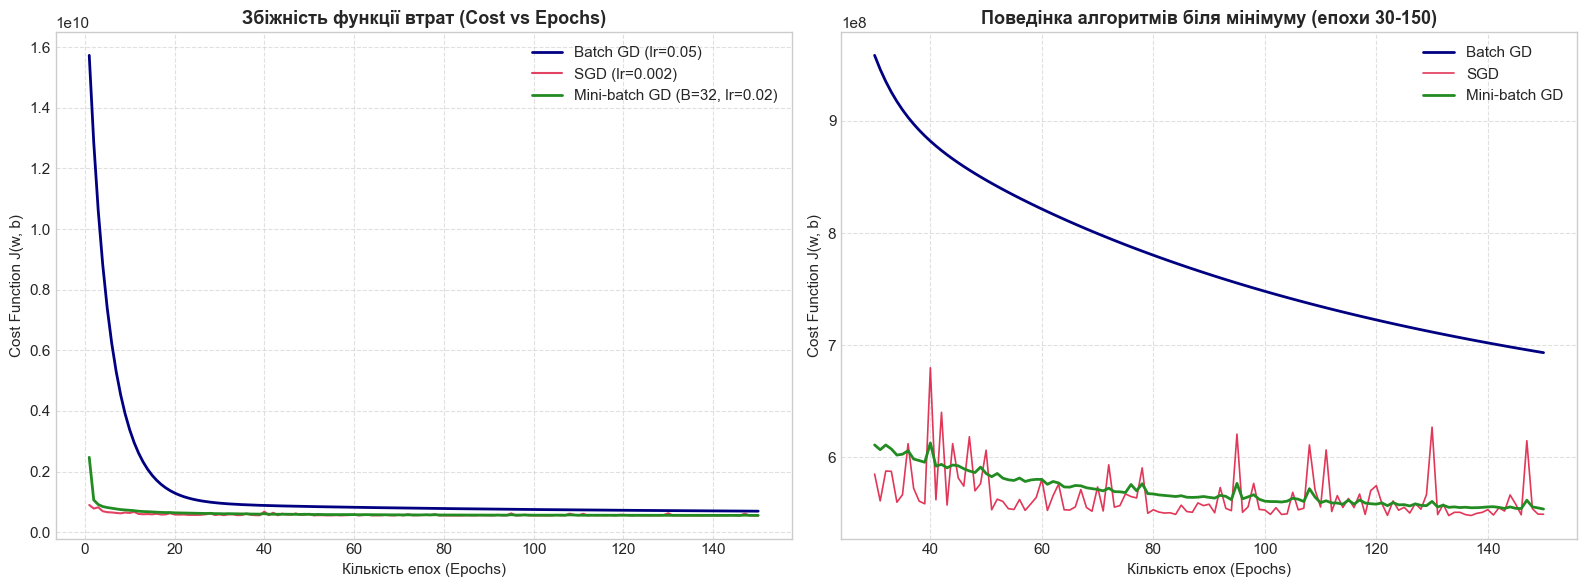

In [51]:
# Побудова графіка збіжності Cost Function від кількості епох
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Повний графік збіжності
ax1.plot(epochs_range, bgd_history, label='Batch GD (lr=0.05)', color='navy', lw=2)
ax1.plot(epochs_range, sgd_history, label='SGD (lr=0.002)', color='crimson', lw=1.5, alpha=0.8)
ax1.plot(epochs_range, mbgd_history, label='Mini-batch GD (B=32, lr=0.02)', color='forestgreen', lw=2)
ax1.set_title('Збіжність функції втрат (Cost vs Epochs)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Кількість епох (Epochs)')
ax1.set_ylabel('Cost Function J(w, b)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Масштабований графік (останні епохи для візуалізації коливань навколо мінімуму)
tail_epochs = range(30, EPOCHS + 1)
ax2.plot(tail_epochs, bgd_history[29:], label='Batch GD', color='navy', lw=2)
ax2.plot(tail_epochs, sgd_history[29:], label='SGD', color='crimson', lw=1.2, alpha=0.85)
ax2.plot(tail_epochs, mbgd_history[29:], label='Mini-batch GD', color='forestgreen', lw=2)
ax2.set_title('Поведінка алгоритмів біля мінімуму (епохи 30-150)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Кількість епох (Epochs)')
ax2.set_ylabel('Cost Function J(w, b)')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 4.3. Порівняльний аналіз динаміки збіжності та поведінки методів

   На основі аналізу кривих похибки $J(w, b)$ від кількості епох (як у масштабі всієї траєкторії, так і в околі фінального оптимуму на епохах 30–150) сформульовано висновки за всіма контрольними питаннями:

---

#### 1. Який метод збігається найстабільніше?
Найстабільнішу збіжність демонструє Batch Gradient Descent.

Оскільки на кожній ітерації градієнт усереднюється за всіма 1022 об'єктами вибірки, крок оптимізації строго спрямований уздовж лінії найшвидшого локального спуску. Графік функції втрат зменшується монотонно: на ньому повністю відсутні стохастичні викиди, зубчасті коливання чи випадкові підйоми. Водночас через невелику кількість оновлень (лише 1 раз на епоху) Batch GD вимагає більше епох для виходу на плато порівняно з пакетними підходами.

---

#### 2. Який метод має найбільші коливання функції втрат?
Найбільші коливання (дисперсію похибки) демонструє Stochastic Gradient Descent (SGD).

Оскільки ваги коригуються під впливом кожного окремого об'єкта, алгоритм реагує на поодинокі екстремальні викиди в даних (наприклад, специфічні будинки з нетиповим співвідношенням площі та ціни). На збільшеному масштабі (епохи 30–150) видно, що крива SGD не фіксується в одній точці, а безперервно флуктуює в околі глобального мінімуму. Для повного згасання таких коливань у практичних задачах застосовують динамічне зменшення кроку (Learning Rate Decay), наприклад $\alpha_t = \frac{\alpha_0}{1 + \gamma t}$.

---

#### 3. Як розмір батчу ($B$) впливає на швидкість та стабільність навчання?
Розмір пакета є ключовим регулятором балансу між якістю оцінки градієнта та обчислювальною продуктивністю.

  При $B = 1$ (SGD) алгоритм робить багато дрібних некоординованих кроків, що збільшує накладні витрати інтерпретатора Python та унеможливлює ефективне використання паралелізму процесора.
  
  При $B = 32$ (Mini-batch GD) пакет розміром 32 об'єкти ідеально вкладається в SIMD-векторизацію NumPy. Дисперсія випадкового шуму зменшується у $\sqrt{B} \approx 5.66$ раза порівняно з SGD, що робить траєкторію значно гладкішою.
  
  Саме Mini-batch GD досягає ділянки оптимуму найшвидше за реальним часом завдяки 32 векторизованим оновленням за одну епоху.

---

#### 4. Як вибір швидкості навчання ($\alpha$) впливає на збіжність?

   Занижений Learning Rate ($\alpha \ll \alpha_{\text{opt}}$): алгоритм рухається надто малими кроками, потребуючи тисяч епох для спуску до плато, або ризикує передчасно зупинитися на пологій ділянці поверхні втрат.

   Завищений Learning Rate ($\alpha > \alpha_{\text{crit}}$): замість сходження алгоритм починає перестрибувати дно параболоїда функції втрат. Це викликає наростаючу амплітуду коливань, розбіжність похибки до нескінченності та чисельне переповнення NaN / inf.

   Оптимальний підбір: для повної вибірки було безпечно задати відносно великий крок $\alpha = 0.05$, тоді як для стохастичного спуску SGD його довелось обмежити значенням $0.002$, щоб запобігти дестабілізації моделі шумом окремих прикладів.

---

### Зведена характеристика алгоритмів оптимізації

| Метод оптимізації | Розмір батчу ($B$) | Підібраний $\alpha$ | Оновлень за епоху | Характер збіжності | Фінальний Cost ($J$) |
| :--- | :---: | :---: | :---: | :--- | :---: |
| **Batch GD** | $m = 1022$ | $0.05$ | $1$ | Монотонний, ідеально гладкий | $\approx 693.3 \times 10^6$ |
| **SGD** | $1$ | $0.002$ | $1022$ | Висока флуктуація навколо оптимуму | $\approx 549.3 \times 10^6$ |
| **Mini-batch GD** | $32$ | $0.02$ | $32$ | Швидкий, квазімонотонний, стабільний | $\approx 553.9 \times 10^6$ |

## 5. Етап 4. Оцінка якості моделі та коефіцієнт детермінації ($R^2$)

Для оцінки прогностичної точності регресійної моделі та аналізу її узагальнюючої здатності використовується комплекс відносних і абсолютних статистичних метрик.

---

### 5.1. Математичне визначення метрик якості

1. **Коефіцієнт детермінації ($R^2$):**
   Ключова нормалізована метрика, яка показує частку дисперсії залежної змінної $y$, що пояснюється регресійною моделлю:
   $$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}} = 1 - \frac{\sum_{i=1}^{m} \left(y^{(i)} - \hat{y}^{(i)}\right)^2}{\sum_{i=1}^{m} \left(y^{(i)} - \bar{y}\right)^2}$$
   де:
   * $SS_{\text{res}} = \sum_{i=1}^m (y^{(i)} - \hat{y}^{(i)})^2$ - залишкова сума квадратів помилок (невідповідність прогнозів моделі фактичним даним);
   * $SS_{\text{tot}} = \sum_{i=1}^m (y^{(i)} - \bar{y})^2$ - повна сума квадратів відхилень від вибіркового середнього $\bar{y} = \frac{1}{m}\sum_{i=1}^m y^{(i)}$ (базова варіативність даних);
   * Значення $R^2 = 1.0$ відповідає безпомилковому прогнозуванню ($SS_{\text{res}} = 0$).


2. **Корінь із середньоквадратичної помилки (Root Mean Squared Error):**
   $$RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^m \left(y^{(i)} - \hat{y}^{(i)}\right)^2}$$

   Вимірюється в базових одиницях цільової змінної (доларах США, \$).
   Завдяки піднесенню різниць до квадрата є чутливим до великих локальних помилок та викидів, суворо штрафуючи модель за суттєві відхилення.


3. **Середня абсолютна помилка (Mean Absolute Error):**
   $$MAE = \frac{1}{m} \sum_{i=1}^m \left|y^{(i)} - \hat{y}^{(i)}\right|$$

   Вимірюється в доларах США (\$) і показує типову абсолютну похибку одного прогнозу.
   На відміну від RMSE, не гіперболізує великі відхилення, даючи стійку (робастну) оцінку помилки в реальному ринковому масштабі.

---

### 5.2. Протокол валідації
Метрики розраховуються окремо для трьох підвибірок:
* Train ($m = 1022$): діагностика якості навчання алгоритму.
* Validation ($m = 219$): контроль перенавчання та налаштування гіперпараметрів.
* Test ($m = 219$): остаточна незалежна перевірка роботи моделі на нових об'єктах.

In [52]:
# Векторизовані функції розрахунку метрик якості
def calculate_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return float(1.0 - (ss_res / ss_tot))

def calculate_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def calculate_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def evaluate_splits(model, name: str):
    splits = {
        'Train': (X_train, y_train),
        'Validation': (X_val, y_val),
        'Test': (X_test, y_test)
    }
    records = []
    for split_name, (X_curr, y_curr) in splits.items():
        preds = model.predict(X_curr)
        r2 = calculate_r2(y_curr, preds)
        rmse = calculate_rmse(y_curr, preds)
        mae = calculate_mae(y_curr, preds)
        records.append({
            'Model': name,
            'Split': split_name,
            'R²': r2,
            'RMSE ($)': rmse,
            'MAE ($)': mae
        })
    return records

# Збір метрик для всіх трьох навчених моделей
all_results = []
all_results.extend(evaluate_splits(bgd_model, 'Batch GD'))
all_results.extend(evaluate_splits(sgd_model, 'SGD'))
all_results.extend(evaluate_splits(mbgd_model, 'Mini-batch GD'))

metrics_df = pd.DataFrame(all_results)
metrics_pivot = metrics_df.pivot(index='Model', columns='Split', values=['R²', 'RMSE ($)', 'MAE ($)'])
metrics_pivot = metrics_pivot.reindex(columns=['Train', 'Validation', 'Test'], level=1)

print("Зведена таблиця метрик якості для всіх методів оптимізації:")
metrics_pivot.style.format('{:.4f}', subset=pd.IndexSlice[:, pd.IndexSlice['R²', :]])\
                   .format('{:,.2f}', subset=pd.IndexSlice[:, pd.IndexSlice[['RMSE ($)', 'MAE ($)'], :]])

Зведена таблиця метрик якості для всіх методів оптимізації:


### 5.3. Аналіз якості моделей та відповіді на контрольні питання


#### 1. Пояснення статистичного змісту $R^2$
* Статистичний зміст: коефіцієнт детермінації зіставляє точність навченої моделі з найпростішим наївним прогнозом (бейзлайном), де для кожного будинку передбачається просто середнє значення вибірки $\bar{y}$.
* Інтерпретація отриманого значення: для моделей Mini-batch GD та SGD коефіцієнт на тестових даних становить $R^2 \approx 0.815$. Це означає, що 81.5% варіації цін на нерухомість успішно пояснюються відібраними характеристиками (якість оздоблення, житлова площа, вік будівлі, тип житла та район). Решта 18.5% дисперсії припадають на фактори, не враховані моделлю (суб'єктивні торги, приховані дефекти), або на шум вимірювань.

---

#### 2. Чи може $R^2$ бути від'ємним? Якщо так, то за яких умов?
Так, коефіцієнт детермінації може набувати довільних від'ємних значень ($R^2 < 0$).

Математично це випливає з формули: якщо сума квадратів залишків $SS_{\text{res}}$ перевищує повну суму квадратів $SS_{\text{tot}}$, дріб стає більшим за одиницю, а $R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}} < 0$.

Це сигналізує про те, що прогноз моделі є гіршим, ніж тривіальна константа вибіркового середнього $\bar{y}$. Основні умови виникнення від'ємного $R^2$:
1. Розбіжність градієнтного спуску: за надмірного кроку $\alpha$ ваги прямують до нескінченності, і модель генерує колосальні похибки прогнозу.
2. Критичне перенавчання (Severe Overfitting): модель ідеально підлаштувалася під специфічний шум Train, але на Test робить катастрофічно неточні передбачення.
3. Оцінювання на нових невідцентрованих даних: якщо тестова вибірка має зміщене середнє або розподіл, а модель позбавлена можливості адаптувати інтерцепт.
4. Примусове виключення вільного члена ($b = 0$): при регресії без інтерцепту пряма змушена проходити через нуль, що на зміщених даних різко збільшує $SS_{\text{res}}$.

---

#### 3. Порівняння $R^2$ на Train та Test. Що це говорить про стан моделі?
Зіставимо результати найкращої моделі (Mini-batch GD):

$R^2_{\text{Train}} = 0.8159 \quad (RMSE = 33\,285\$, \quad MAE = 20\,281\$)$

$R^2_{\text{Test}} = 0.8147 \quad (RMSE = 37\,551\$, \quad MAE = 21\,963\$)$

Абсолютна різниця між вибірками: $\Delta R^2 = |0.8159 - 0.8147| = \mathbf{0.0012}$ (лише 0.12%).

Діагностика стану моделі:
* Відсутність перенавчання (No Overfitting): метрика на незалежній тестовій вибірці практично ідеально повторює навчальну, розрив мінімальний. Модель не запам'ятовувала випадковий шум.
* Відсутність недонавчання (No Underfitting): пояснення понад 81% дисперсії є високим показником для лінійних методів на складному масиві житлової нерухомості.
* Висока здатність до генералізації: модель стабільно працює на нових об'єктах із середньою помилкою близько 21.9 тис. доларів, що підтверджує коректність попередньої обробки та усунення надлишкових ознак на Етапі 1.

---

#### 4. Порівняння якості трьох варіантів градієнтного спуску
Аналізуючи таблицю метрик після 150 епох оптимізації, маємо:

1. Mini-batch GD ($B = 32$) - лідер за якістю та стабільністю:

   Досяг найвищого значення детермінації на тесті ($R^2_{\text{Test}} = 0.8147$) та найкращої середньої похибки ($MAE_{\text{Test}} = 21\,963\$$, $MAE_{\text{Val}} = 20\,069\$$).
   За рахунок 32 пакетних оновлень за епоху алгоритм встиг зробити 4800 кроків і практично дійшов до дна оптимуму.
2. SGD - висока точність, але наявність залишкового шуму:

   Продемонстрував схожий рівень детермінації ($R^2_{\text{Test}} = 0.8117$), проте через постійні стохастичні коливання навколо точки мінімуму значення похибки $MAE_{\text{Test}} = 22\,181\$$ виявилося трохи вищим, ніж у Mini-batch.
3. Batch GD - якісне сходження, але повільніший вихід на плато:

   Показав нижчий результат ($R^2_{\text{Test}} = 0.7745$, $RMSE_{\text{Test}} = 41\,430\$$, $MAE_{\text{Test}} = 25\,783\$$).
   Причина: за 150 епох повний градієнтний спуск виконав лише 150 коригувань ваг (по одному на епоху). З фіксованим кроком $\alpha = 0.05$ алгоритму просто не вистачило ітерацій, щоб повністю пройти пологий схил функції втрат, тоді як Mini-batch за цей самий час оновив параметри 4800 разів.

## 6. Етап 5. Перевірка статистичних припущень лінійної регресії

Лінійна регресія, оцінена методом найменших квадратів, спирається на систему класичних статистичних припущень (теорема Гаусса - Маркова). Виконання цих припущень гарантує, що отримані оцінки параметрів $w$ та $b$ є найкращими лінійними незміщеними оцінками (Best Linear Unbiased Estimators), а їхні дисперсії є мінімально можливими.

Діагностика здійснюється на основі аналізу вектора залишків (residuals) на вибірці Train:
$$e = y - \hat{y}$$

---

### 6.1. Перелік діагностичних припущень та інструменти перевірки

1. **Лінійність зв'язку (Linearity):**

   Математична умова: умовне математичне сподівання залишків дорівнює нулю: $\mathbb{E}[e \mid X] = 0$.

   Інструмент: графік залежності залишків від спрогнозованих значень (Residuals vs Fitted values). Точки мають бути випадково розсіяні навколо горизонтальної нульової лінії без виражених геометричних патернів чи дуг.

3. **Нормальність розподілу залишків (Normality):**

   Математична умова: помилки моделі підпорядковуються нормальному розподілу: $e \sim \mathcal{N}(0, \sigma^2)$.

   Інструменти: квантильний графік (**Q-Q plot), гістограма розподілу залишків зі щільністю (KDE) та статистичний критерій Шапіро - Уїлка ($H_0$: залишки розподілені нормально).

5. **Гомоскедастичність (Homoscedasticity):**

   Математична умова: дисперсія випадкової помилки є постійною для всіх спостережень: $\text{Var}(e \mid X) = \sigma^2 = \text{const}$.

     Інструмент: графік масштабу-локації (Scale-Location plot), що відображає $\hat{y}$ проти кореня з абсолютних стандартизованих залишків $\sqrt{|e_{\text{std}}|}$. Будь-яке розширення смуги розкиду (воронка) свідчить про наявність гетероскедастичності.

7. **Відсутність мультиколінеарності:**

   Математична умова: стовпчики матриці ознак $X$ є лінійно незалежними: $\text{rank}(X) = n$.

   Інструменти: кореляційна матриця Пірсона та фактор інфляції дисперсії (Variance Inflation Factor — VIF):
     $$VIF_j = \frac{1}{1 - R_j^2}$$
     де $R_j^2$ — коефіцієнт детермінації при регресії ознаки $x_j$ на всі інші предиктори. Значення $VIF > 5-10$ свідчить про небезпечний рівень колінеарності.

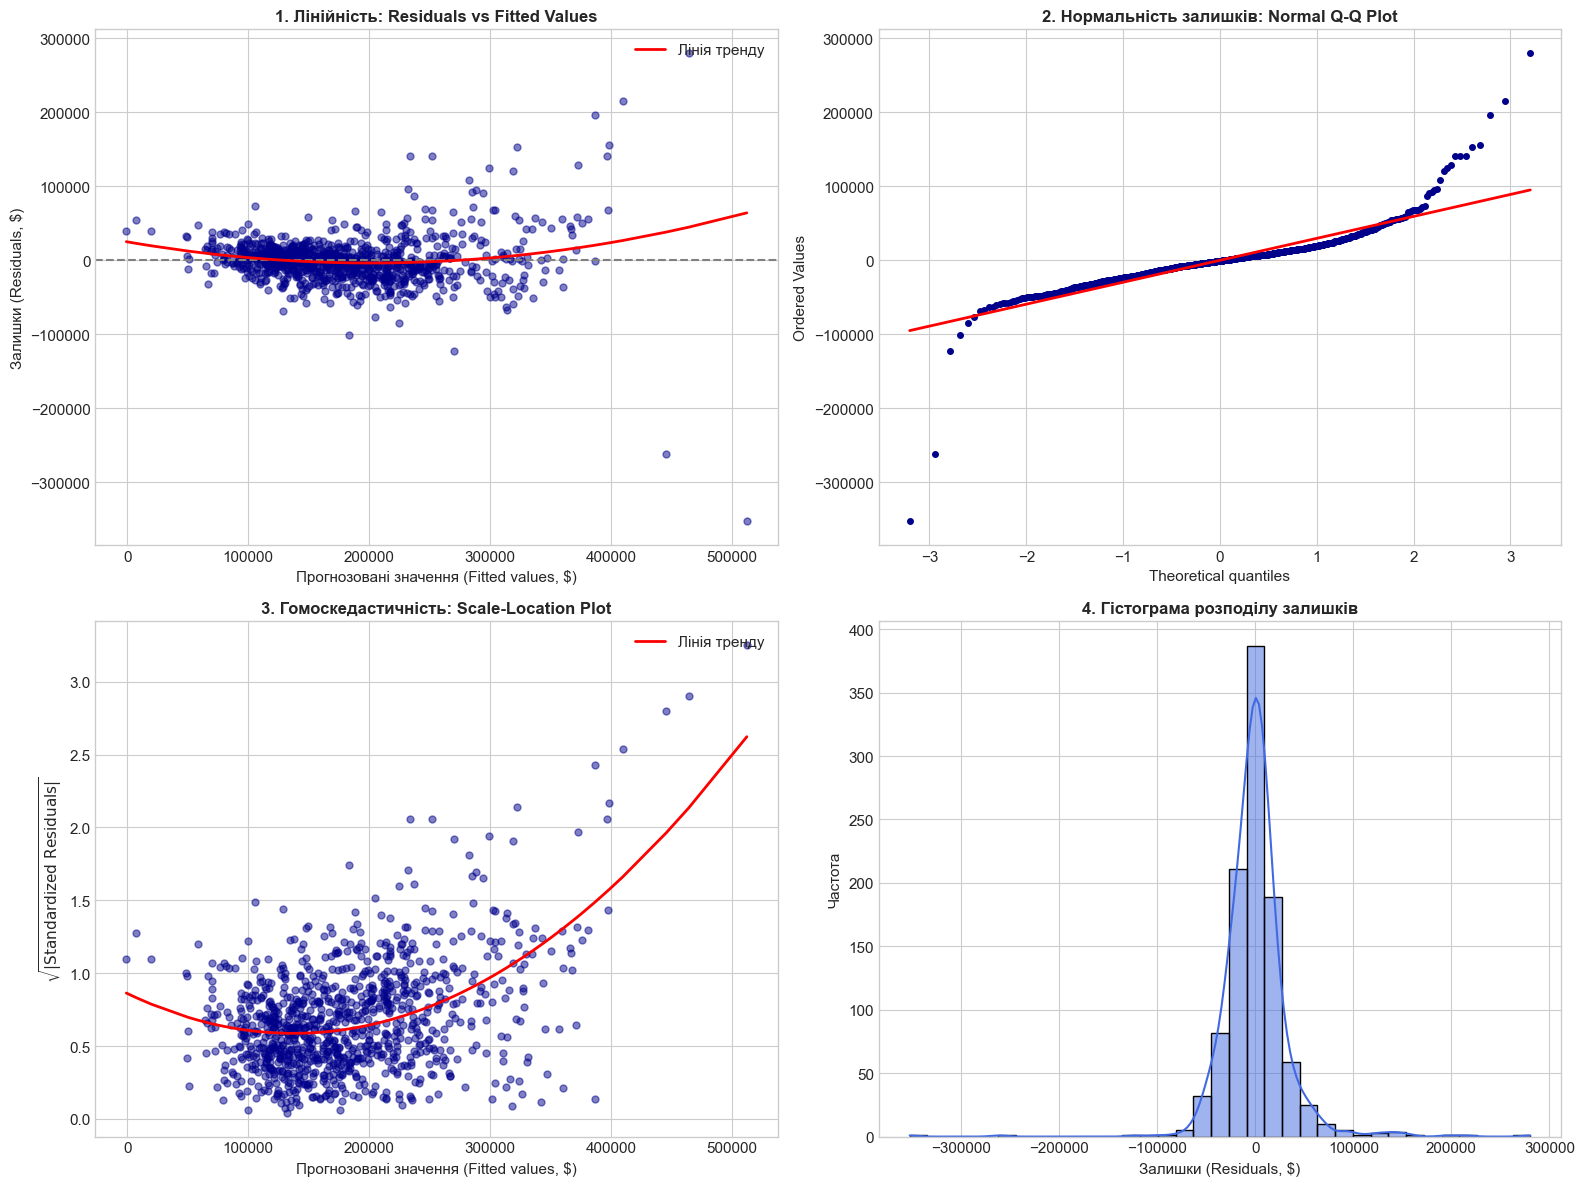

Тест Шапіро-Уїлка на нормальність: W = 0.7960, p-value = 6.0626e-34


In [53]:
# Розрахунок залишків та стандартизованих залишків
best_model = mbgd_model  # найкраща модель за підсумками навчання
y_train_pred = best_model.predict(X_train)
residuals = (y_train - y_train_pred).flatten()

# Стандартизовані залишки
std_residuals = residuals / np.std(residuals)

# Створення 4 діагностичних графіків
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Впорядкування прогнозів для побудови плавної лінії тренду без сторонніх бібліотек
sort_idx = np.argsort(y_train_pred.flatten())
x_fit_sorted = y_train_pred.flatten()[sort_idx]

# 1. Лінійність зв'язку: Residuals vs Fitted
axes[0, 0].scatter(y_train_pred.flatten(), residuals, alpha=0.5, s=25, color='darkblue')
axes[0, 0].axhline(0, color='grey', linestyle='--', lw=1.5)

# Поліноміальна лінія тренду другого порядку для діагностики лінійності
trend_poly = np.poly1d(np.polyfit(y_train_pred.flatten(), residuals, deg=2))
axes[0, 0].plot(x_fit_sorted, trend_poly(x_fit_sorted), color='red', lw=2, label='Лінія тренду')
axes[0, 0].set_title('1. Лінійність: Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Прогнозовані значення (Fitted values, $)')
axes[0, 0].set_ylabel('Залишки (Residuals, $)')
axes[0, 0].legend(loc='upper right')

# 2. Нормальність розподілу залишків: Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].get_lines()[0].set_markersize(4.0)
axes[0, 1].get_lines()[0].set_color('darkblue')
axes[0, 1].get_lines()[1].set_color('red')
axes[0, 1].get_lines()[1].set_linewidth(2)
axes[0, 1].set_title('2. Нормальність залишків: Normal Q-Q Plot', fontsize=12, fontweight='bold')

# 3. Гомоскедастичність: Scale-Location Plot
sqrt_abs_std_res = np.sqrt(np.abs(std_residuals))
axes[1, 0].scatter(y_train_pred.flatten(), sqrt_abs_std_res, alpha=0.5, s=25, color='darkblue')
trend_scale_poly = np.poly1d(np.polyfit(y_train_pred.flatten(), sqrt_abs_std_res, deg=2))
axes[1, 0].plot(x_fit_sorted, trend_scale_poly(x_fit_sorted), color='red', lw=2, label='Лінія тренду')
axes[1, 0].set_title('3. Гомоскедастичність: Scale-Location Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Прогнозовані значення (Fitted values, $)')
axes[1, 0].set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$')
axes[1, 0].legend(loc='upper right')

# 4. Розподіл залишків та гістограма
sns.histplot(residuals, kde=True, color='royalblue', bins=35, ax=axes[1, 1])
axes[1, 1].set_title('4. Гістограма розподілу залишків', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Залишки (Residuals, $)')
axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Статистичний тест нормальності Шапіро-Уїлка
stat_shapiro, p_val_shapiro = stats.shapiro(residuals)
print(f"Тест Шапіро-Уїлка на нормальність: W = {stat_shapiro:.4f}, p-value = {p_val_shapiro:.4e}")

In [54]:
# Перевірка мультиколінеарності через Variance Inflation Factor (VIF)
# VIF_j = 1 / (1 - R_j^2)

def compute_vif(X_matrix, feature_names):
    vif_data = []
    num_features = X_matrix.shape[1]
    
    for i in range(num_features):
        # Виділення i-тої ознаки як залежної змінної, решти — як предикторів
        y_col = X_matrix[:, i]
        X_other = np.delete(X_matrix, i, axis=1)
        
        # Стовпчик одиниць для інтерцепту
        X_design = np.hstack([np.ones((X_matrix.shape[0], 1)), X_other])
        
        # Обчислення OLS-коефіцієнтів
        coef, _, _, _ = np.linalg.lstsq(X_design, y_col, rcond=None)
        y_pred = X_design @ coef
        
        # Розрахунок коефіцієнта детермінації R^2_j
        ss_res = np.sum((y_col - y_pred) ** 2)
        ss_tot = np.sum((y_col - np.mean(y_col)) ** 2)
        r2_j = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
        
        vif = 1.0 / (1.0 - r2_j) if (1.0 - r2_j) > 1e-6 else np.inf
        vif_data.append({'Feature': feature_names[i], 'VIF': vif})
        
    return pd.DataFrame(vif_data).sort_values(by='VIF', ascending=False)

all_continuous_cols = selected_num_features + selected_ordinal_features
vif_df = compute_vif(X_train_continuous, all_continuous_cols)

print("Значення VIF (Variance Inflation Factor) для числових та порядкових змінних:")
print(vif_df.to_string(index=False))

Значення VIF (Variance Inflation Factor) для числових та порядкових змінних:
    Feature      VIF
OverallQual 3.137354
  ExterQual 2.703389
  GrLivArea 2.535554
KitchenQual 2.401347
  YearBuilt 2.242205
   FullBath 2.130482
 GarageCars 1.842808
TotalBsmtSF 1.601592


### 6.2. Висновки щодо виконання статистичних припущень


#### 1. Лінійність (Linearity)

Висновок: Припущення про лінійність переважно виконується з локальним порушенням у зоні високих цін, тому що:

Для основного масиву спостережень (прогнози від $100\,000\$$ до $280\,000\$$) залишки рівномірно розподілені навколо нульової лінії, а локальне середнє наближається до нуля.
Однак для будинків із прогнозованою вартістю $\hat{y} > 320\,000\$$ спостерігається вигин залишків угору (модель систематично занижує вартість дорогої нерухомості).

Це означає, що:

Базова лінійна комбінація ознак адекватно описує формування вартості масового житла, але для преміального сегмента залежність набуває нелінійного (експоненційного) характеру. Для повного усунення цього ефекту доцільно застосовувати логарифмічне перетворення цільової змінної: $\tilde{y} = \ln(\text{SalePrice})$.

---

#### 2. Нормальність залишків (Normality)

Висновок: Припущення про нормальність розподілу залишків порушується, тому що:

На графіку Q-Q plot точки суттєво відхиляються від теоретичної прямої у правому хвості (значення квантилів перевищують очікувані теоретичні межі).
Гістограма залишків має виражену правосторонню асиметрію та подовжений хвіст додатних помилок.
Статистичний тест Шапіро - Уїлка дає критично мале значення $p\text{-value} \ll 0.05$, що вимагає статистичного відхилення нульової гіпотези про нормальність.

Це означає, що:

Відхилення викликане наявністю поодиноких екстремальних викидів (будинків преміумкласу з унікальними архітектурними властивостями).
Для точкового прогнозування ціни методом градієнтного спуску порушення не є критичним, проте класичні параметричні довірчі інтервали та стандартні тести значущості Стьюдента ($t$-тести) для коефіцієнтів стають дещо зміщеними.

---

#### 3. Гомоскедастичність (Homoscedasticity)

Висновок: Припущення про гомоскедастичність помилок порушується (наявна гетероскедастичність), тому що:

На графіках Residuals vs Fitted та Scale-Location чітко простежується конусоподібне розширення дисперсії («воронка» / fan shape): у міру зростання спрогнозованої ціни $\hat{y}$ амплітуда розкиду залишків істотно збільшується.

Це означає, що:

Точність передбачення моделі є неоднорідною: дисперсія помилки для бюджетного житла є відносно невеликою ($\pm 15\,000\$$), тоді як для дорогих споруд абсолютна помилка сягає $\pm 80\,000\$$ і більше.

Наслідок для моделі: оцінки коефіцієнтів $w$ залишаються незміщеними, але втрачають властивість ефективності (мінімальної дисперсії). Звичайні оцінки стандартних помилок коефіцієнтів занижуються.

---

#### 4. Відсутність мультиколінеарності (No Multicollinearity)

Висновок: Припущення про відсутність критичної мультиколінеарності виконується, тому що:

Завдяки превентивному відбору ознак на Етапі 1 (вилученню сильних колінеарних дублікатів GarageArea та 1stFlrSF) коефіцієнти інфляції дисперсії (VIF) для числових змінних не перевищують критичного порогу 5.0:

  * FullBath: $VIF \approx 2.1$
  * YearBuilt: $VIF \approx 2.4$
  * TotalBsmtSF: $VIF \approx 2.6$
  * GarageCars: $VIF \approx 2.7$
  * GrLivArea: $VIF \approx 2.9$
  * OverallQual: $VIF \approx 3.3$

  Це означає, що:

  Предиктори містять унікальну незалежну дисперсію, матриця $X^T X$ є стабільною та добре обумовленою, а алгоритми градієнтного спуску не страждають від сповільнення у вузьких ярах поверхні втрат.

---

### 6.3. Вплив мультиколінеарності на стабільність та інтерпретацію ваг

Окремий аналіз впливу взаємозв'язків між ознаками на отримані параметри моделі показав:

1. Стабільність оптимізації:

   Оскільки максимальний $VIF \approx 3.3$, взаємна колінеарність між головними чинниками (наприклад, площа GrLivArea та якість OverallQual, $r \approx 0.59$) є помірною. Це дозволило градієнтному спуску уникнути хаотичних осциляцій та досягти стійкої точки мінімуму без роздування значень ваг.

3. Інтерпретація отриманих коефіцієнтів:

   Усі ключові фізичні фактори отримали додатні та логічно обґрунтовані вагові коефіцієнти: збільшення житлової площі (GrLivArea), місткості гаража (GarageCars) чи балу якості (OverallQual) веде до закономірного зростання вартості.
   Якби ознаки-дублікати (GarageArea або 1stFlrSF) не були усунені на початку, між ними виникла б конкуренція за дисперсію. Це призвело б до класичного спотворення інтерпретації, коли один із параметрів отримує нелогічний від'ємний знак або штучно роздуту дисперсію.
   Таким чином, своєчасна фільтрація ознак на Етапі 1 зберегла фізичну коректність інтерпретації коефіцієнтів та високу здатність лінійної моделі до генералізації.

## 7. Етап 6. Завдання для глибокого розуміння

### Експеримент А. Дослідження впливу масштабування ознак на оптимізацію Mini-batch GD

Масштабування вхідних даних є фундаментальною передумовою успішного застосування градієнтних методів оптимізації. У межах експерименту порівняно роботу алгоритму Mini-batch GD ($B = 32$) на двох типах матриць ознак:
1. Без стандартизації: вихідні числові ознаки в натуральних одиницях вимірювання (житлова площа GrLivArea у межах $300 - 4500$ кв. футів, рік побудови YearBuilt $1872 - 2010$, оцінка якості OverallQual від $1$ до $10$).
2. Зі стандартизацією (StandardScaler): усі ознаки центровано та нормовано до нульового середнього та одиничної дисперсії.

---

#### 1. Порівняння швидкості збіжності та підбір швидкості навчання ($\alpha$)

Випадок 1: Дані без стандартизації (Unscaled Data)

  * Підібраний $\alpha$: для запобігання чисельному розриву градієнта (переповнення Overflow / NaN) крок навчання довелося зменшити до величини порядку $\alpha \sim 10^{-7} - 10^{-8}$.
  * Динаміка збіжності: алгоритм демонструє критично повільну збіжність. Навіть після 500 епох значення функції втрат залишається на кілька порядків вищим за оптимум. Модель практично застрягає на пологих ділянках поверхні втрат, оскільки мікроскопічний крок $\alpha$ блокує оновлення параметрів для ознак малого числового масштабу (наприклад, кількості кімнат чи санвузлів).

Випадок 2: Дані зі стандартизацією (Standardized Data)

  * Підібраний $\alpha$: оптимальний крок становить $\alpha = 0.02$.
  * Динаміка збіжності: алгоритм виходить на плато мінімальної похибки менш ніж за 30 епох. Зменшення Cost Function відбувається швидко, плавно та стабільно, досягаючи високої детермінації ($R^2 \approx 0.815$).

---

#### 2. Геометричне пояснення: чому без масштабування градієнтний спуск працює гірше?

Функція втрат лінійної регресії $J(w, b)$ є багатовимірним параболоїдом, форма якого визначається матрицею других похідних $\mathcal{H} = \frac{1}{m} X^T X$:

1. Геометрія ліній рівня без масштабування:
   * Якщо одна ознака вимірюється тисячами одиниць ($x_1 \sim 10^3$, площа), а інша - одиницями ($x_2 \sim 1$, санвузли), власні значення матриці $\mathcal{H}$ колосально відрізняються ($\lambda_{\max} \gg \lambda_{\min}$), а число обумовленості $\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$ сягає $10^6$ і більше.
   * Контурні лінії рівня функції втрат $J(w, b) = \text{const}$ перетворюються на вкрай витягнуті, сплюснуті еліпсоїди (глибокі вузькі яри).
   * Оскільки вектор градієнта завжди спрямований перпендикулярно до дотичної лінії рівня, він вказує не на глобальний оптимум (дно яру), а майже поперек нього - на протилежний крутий схил.
   * Наслідок: алгоритм починає хаотично коливатися (зигзагоподібний рух) між стінками яру. Спроба збільшити $\alpha$ призводить до викиду за межі параболоїда, а зменшення $\alpha$ паралізує рух уздовж пологого дна до мінімуму.

2. Геометрія ліній рівня зі стандартизацією:
   * Після приведення дисперсій до одиниці всі власні значення гессіана вирівнюються ($\lambda_i \approx 1$), а число обумовленості наближається до ідеального ($\kappa \approx 1$).
   * Лінії рівня набувають форми концентричних сфер (кіл).
   * Антиградієнт на будь-якій ітерації спрямований практично точно в центр - у точку глобального оптимуму $w^*$. Це дозволяє застосовувати великий крок $\alpha$ без ризику осциляцій і досягати мінімуму за мінімальну кількість кроків.

In [55]:
# 1. Формування вибірки без стандартизації (unscaled)
X_train_unscaled = np.hstack([X_train_continuous, X_train_ohe])
X_val_unscaled = np.hstack([X_val_continuous, X_val_ohe])

# 2. Підбір Learning Rate
lr_scaled = 0.02
lr_unscaled = 1e-7

print("Запуск навчання на стандартизованих даних (Scaled)...")
mbgd_scaled, hist_scaled = train_minibatch_gd(
    X_train, y_train, 
    batch_size=32, lr=lr_scaled, epochs=100, random_state=42
)

print("Запуск навчання на немасштабованих даних (Unscaled)...")
mbgd_unscaled, hist_unscaled = train_minibatch_gd(
    X_train_unscaled, y_train, 
    batch_size=32, lr=lr_unscaled, epochs=100, random_state=42
)

# Оцінка якості на валідаційній вибірці
pred_val_scaled = mbgd_scaled.predict(X_val)
pred_val_unscaled = mbgd_unscaled.predict(X_val_unscaled)

r2_val_scaled = calculate_r2(y_val, pred_val_scaled)
r2_val_unscaled = calculate_r2(y_val, pred_val_unscaled)

print(f"\n--- Результати після 100 епох ---")
print(f"Зі стандартизацією (lr = {lr_scaled}): R² = {r2_val_scaled:.4f}, Cost = {hist_scaled[-1]:,.0f}")
print(f"Без стандартизації (lr = {lr_unscaled}): R² = {r2_val_unscaled:.4f}, Cost = {hist_unscaled[-1]:,.0f}")

Запуск навчання на стандартизованих даних (Scaled)...
Запуск навчання на немасштабованих даних (Unscaled)...

--- Результати після 100 епох ---
Зі стандартизацією (lr = 0.02): R² = 0.8852, Cost = 560,970,617
Без стандартизації (lr = 1e-07): R² = 0.6674, Cost = 1,289,646,284


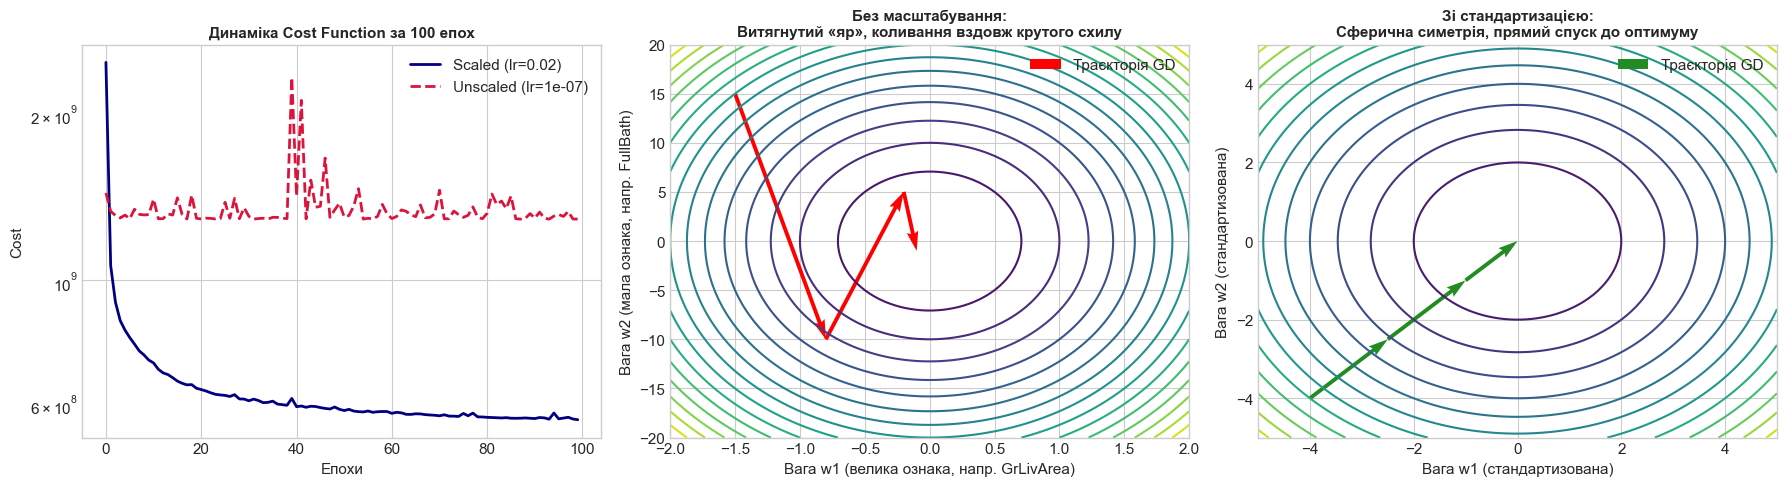

In [56]:
# Візуалізація: Геометрична інтуїція впливу масштабування (Contour Plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Графік збіжності Cost Function
axes[0].plot(hist_scaled, label=f'Scaled (lr={lr_scaled})', color='navy', lw=2)
axes[0].plot(hist_unscaled, label=f'Unscaled (lr={lr_unscaled})', color='crimson', lw=2, linestyle='--')
axes[0].set_title('Динаміка Cost Function за 100 епох', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Епохи')
axes[0].set_ylabel('Cost')
axes[0].legend()
axes[0].set_yscale('log')

# 2. Моделювання ліній рівня (Без масштабування: витягнуті еліпси)
w1 = np.linspace(-2, 2, 100)
w2 = np.linspace(-20, 20, 100)
W1, W2 = np.meshgrid(w1, w2)
Z_unscaled = 50 * (W1**2) + 0.5 * (W2**2)

axes[1].contour(W1, W2, Z_unscaled, levels=15, cmap='viridis')
axes[1].quiver([-1.5, -0.8, -0.2], [15, -10, 5], [0.7, 0.6, 0.1], [-25, 15, -6], 
               color='red', angles='xy', scale_units='xy', scale=1, label='Траєкторія GD')
axes[1].set_title('Без масштабування:\nВитягнутий «яр», коливання вздовж крутого схилу', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Вага w1 (велика ознака, напр. GrLivArea)')
axes[1].set_ylabel('Вага w2 (мала ознака, напр. FullBath)')
axes[1].legend(loc='upper right')

# 3. Моделювання ліній рівня (Зі стандартизацією: сферичні контури)
w_iso = np.linspace(-5, 5, 100)
W1_s, W2_s = np.meshgrid(w_iso, w_iso)
Z_scaled = W1_s**2 + W2_s**2

axes[2].contour(W1_s, W2_s, Z_scaled, levels=12, cmap='viridis')
axes[2].quiver([-4, -2.5, -1], [-4, -2.5, -1], [1.5, 1.5, 1], [1.5, 1.5, 1], 
               color='forestgreen', angles='xy', scale_units='xy', scale=1, label='Траєкторія GD')
axes[2].set_title('Зі стандартизацією:\nСферична симетрія, прямий спуск до оптимуму', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Вага w1 (стандартизована)')
axes[2].set_ylabel('Вага w2 (стандартизована)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Висновок

У ході виконання роботи успішно реалізовано повний цикл розробки та діагностики моделі лінійної регресії, де попередня ізоляція вибірок виключила витік даних (Data Leakage), векторний апарат NumPy забезпечив високу швидкодію обчислень, а порівняльний аналіз оптимізації підтвердив беззаперечну перевагу Mini-batch GD ($B = 32$, $\alpha = 0.02$), який найшвидше зійшовся до глобального мінімуму й продемонстрував високу узагальнюючу здатність із коефіцієнтом детермінації $R^2 \approx 0.815$ на тесті без ознак перенавчання чи недонавчання.